In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted!")

Mounted at /content/drive
✓ Google Drive mounted!


In [30]:
import pandas as pd
import numpy as np

# 1. LOADING DATA

train_df = pd.read_csv("/content/drive/MyDrive/ML/train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/ML/test.csv")
survival_df = pd.read_csv("/content/drive/MyDrive/ML/gender_submission.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
print("Survival File Shape:", survival_df.shape)
print(survival_df.head())


Train Shape: (891, 12)
Test Shape: (418, 11)
Survival File Shape: (418, 2)
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


In [31]:
# ============================================================
# 2. CHECK COLUMN ORDER
# ============================================================

print("\nTrain Columns:")
print(train_df.columns.tolist())

print("\nTest Columns:")
print(test_df.columns.tolist())




Train Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Test Columns:
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [32]:
# ============================================================
# 3. ADD Survived COLUMN TO TEST DATA
# ============================================================
# Test dataset does not contain target column

test_df["Survived"] = np.nan

# ============================================================
# 4. MAKE SAME COLUMN SEQUENCE
# ============================================================

final_columns = [
    'PassengerId',
    'Survived',
    'Pclass',
    'Name',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Ticket',
    'Fare',
    'Cabin',
    'Embarked'
]

train_df = train_df[final_columns]
test_df = test_df[final_columns]



In [33]:
# ============================================================
# 5. MERGE TRAIN + TEST
# ============================================================

combined_df = pd.concat([train_df, test_df], ignore_index=True)

print("\nCombined Shape:", combined_df.shape)




Combined Shape: (1309, 12)


In [34]:
# ============================================================
# ADD SURVIVED VALUES FOR TEST PASSENGERS
# ============================================================
# ============================================================
# MERGE SURVIVAL VALUES INTO COMBINED DATA
# ============================================================

combined_df = combined_df.merge(
    survival_df,
    on='PassengerId',
    how='left',
    suffixes=('', '_new')
)

# ============================================================
# FILL MISSING SURVIVED VALUES
# ============================================================

combined_df['Survived'] = combined_df['Survived'].fillna(
    combined_df['Survived_new']
)

# Remove extra column
combined_df.drop(columns=['Survived_new'], inplace=True)

# ============================================================
# CHECK RESULT
# ============================================================

print(combined_df[['PassengerId', 'Survived']].tail(20))

# ============================================================
# SAVE UPDATED FILE
# ============================================================

combined_df.to_csv(
    "titanic_combined_with_survival.csv",
    index=False
)

print("\nUpdated file saved as:")
print("titanic_combined_with_survival.csv")

      PassengerId  Survived
1289         1290       0.0
1290         1291       0.0
1291         1292       1.0
1292         1293       0.0
1293         1294       1.0
1294         1295       0.0
1295         1296       0.0
1296         1297       0.0
1297         1298       0.0
1298         1299       0.0
1299         1300       1.0
1300         1301       1.0
1301         1302       1.0
1302         1303       1.0
1303         1304       1.0
1304         1305       0.0
1305         1306       1.0
1306         1307       0.0
1307         1308       0.0
1308         1309       0.0

Updated file saved as:
titanic_combined_with_survival.csv


In [16]:
combined_df = pd.read_csv("/content/drive/MyDrive/ML/titanic_combined_with_survival.csv")

In [35]:
# ============================================================
# 6. CHECK DUPLICATES BASED ON PRIMARY KEY
# ============================================================

duplicate_ids = combined_df[
    combined_df.duplicated(subset=['PassengerId'], keep=False)
]

print("\nDuplicate Passenger IDs Count:", duplicate_ids.shape[0])

if duplicate_ids.shape[0] > 0:
    print("\nDuplicate Passenger IDs:")
    print(duplicate_ids[['PassengerId']])
else:
    print("\nNo duplicate Passenger IDs found.")




Duplicate Passenger IDs Count: 0

No duplicate Passenger IDs found.


In [18]:
# ============================================================
# 7. REMOVE DUPLICATES (IF ANY)
# ============================================================

combined_df = combined_df.drop_duplicates(
    subset=['PassengerId'],
    keep='first'
)

print("\nShape After Removing Duplicates:", combined_df.shape)




Shape After Removing Duplicates: (1309, 12)


In [36]:
# ============================================================
# 8. CHECK MISSING VALUES
# ============================================================

missing_values = combined_df.isnull().sum()

print("\nMissing Values:")
print(missing_values)

print("\nMissing Percentage:")
print((missing_values / len(combined_df)) * 100)




Missing Values:
PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

Missing Percentage:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.091673
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.076394
Cabin          77.463713
Embarked        0.152788
dtype: float64


In [37]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

# ----- AGE -----
# Fill missing Age values with median

combined_df['Age'] = combined_df['Age'].fillna(
    combined_df['Age'].mean()
)

# ----- FARE -----
# Fill missing Fare with median

combined_df['Fare'] = combined_df['Fare'].fillna(
    combined_df['Fare'].mean()
)

# ----- EMBARKED -----
# Fill missing Embarked with mode

combined_df['Embarked'] = combined_df['Embarked'].fillna(
    combined_df['Embarked'].mode()[0]
)

# ----- CABIN -----
# Drop Cabin column because too many missing values

combined_df.drop(columns=['Cabin'], inplace=True)

# ============================================================
# CHECK MISSING VALUES AGAIN
# ============================================================

print("\nMissing Values After Treatment:\n")
print(combined_df.isnull().sum())


Missing Values After Treatment:

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [38]:
# ============================================================
# 9. DATA TYPES
# ============================================================

print("\nData Types:")
print(combined_df.dtypes)




Data Types:
PassengerId      int64
Survived       float64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


In [39]:
# ============================================================
# 13. ENCODE CATEGORICAL VARIABLES
# ============================================================

# Sex Encoding
combined_df['Sex'] = combined_df['Sex'].map({
    'male': 0,
    'female': 1
})

# ============================================================
# 14. FINAL INFO
# ============================================================

print("\nFinal Dataset Info:")
print(combined_df.info())

print("\nFirst 5 Rows:")
print(combined_df.head())




Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   int64  
 5   Age          1309 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1309 non-null   float64
 10  Embarked     1309 non-null   object 
dtypes: float64(3), int64(5), object(3)
memory usage: 112.6+ KB
None

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1       0.0       3   
1            2       1.0       1   
2            3       1.0       3   
3            4       1.0       1   
4            5       0.0       3   

                         

In [40]:
# ============================================================
#  ONE HOT ENCODING
# ============================================================

if 'Embarked' in combined_df.columns:

    embarked_dummies = pd.get_dummies(
        combined_df['Embarked'],
        prefix='Embarked',
        dtype=int
    )

    combined_df = pd.concat([combined_df, embarked_dummies], axis=1)

    combined_df.drop(columns=['Embarked'], inplace=True)

    print("Embarked encoded successfully")

else:
    print("Embarked column already missing — encoding skipped")

Embarked encoded successfully


In [41]:
# ============================================================
# 15. SAVE CLEANED FILE
# ============================================================

combined_df.to_csv("titanic_combined_cleaned.csv", index=False)

print("\nCleaned file saved as:")
print("titanic_combined_cleaned.csv")


Cleaned file saved as:
titanic_combined_cleaned.csv


In [43]:
# ============================================================
# CHECK CLASS IMBALANCE
# ============================================================

# Only original training portion
train_data = combined_df[
    combined_df['PassengerId'] <= 891
]

print("Train Shape:", train_data.shape)

# Target distribution
print("\nSurvived Value Counts:\n")
print(train_data['Survived'].value_counts())

print("\nSurvived Percentage:\n")
print(
    train_data['Survived'].value_counts(normalize=True) * 100
)

Train Shape: (891, 13)

Survived Value Counts:

Survived
0.0    549
1.0    342
Name: count, dtype: int64

Survived Percentage:

Survived
0.0    61.616162
1.0    38.383838
Name: proportion, dtype: float64


Correlation Matrix:

             PassengerId  Survived    Pclass       Sex       Age     SibSp  \
PassengerId     1.000000 -0.020370 -0.038354 -0.013406  0.025731 -0.055224   
Survived       -0.020370  1.000000 -0.264710  0.688371 -0.048483  0.002370   
Pclass         -0.038354 -0.264710  1.000000 -0.124617 -0.366371  0.060832   
Sex            -0.013406  0.688371 -0.124617  1.000000 -0.057397  0.109609   
Age             0.025731 -0.048483 -0.366371 -0.057397  1.000000 -0.190747   
SibSp          -0.055224  0.002370  0.060832  0.109609 -0.190747  1.000000   
Parch           0.008942  0.108919  0.018322  0.213125 -0.130872  0.373587   
Fare            0.031416  0.233568 -0.558477  0.185484  0.171521  0.160224   
Embarked_C      0.048101  0.121156 -0.269658  0.066564  0.076179 -0.048396   
Embarked_Q      0.011585  0.040950  0.230491  0.088651 -0.012718 -0.048678   
Embarked_S     -0.049836 -0.133020  0.091320 -0.115193 -0.059153  0.073709   

                Parch      Fare  Embarked_

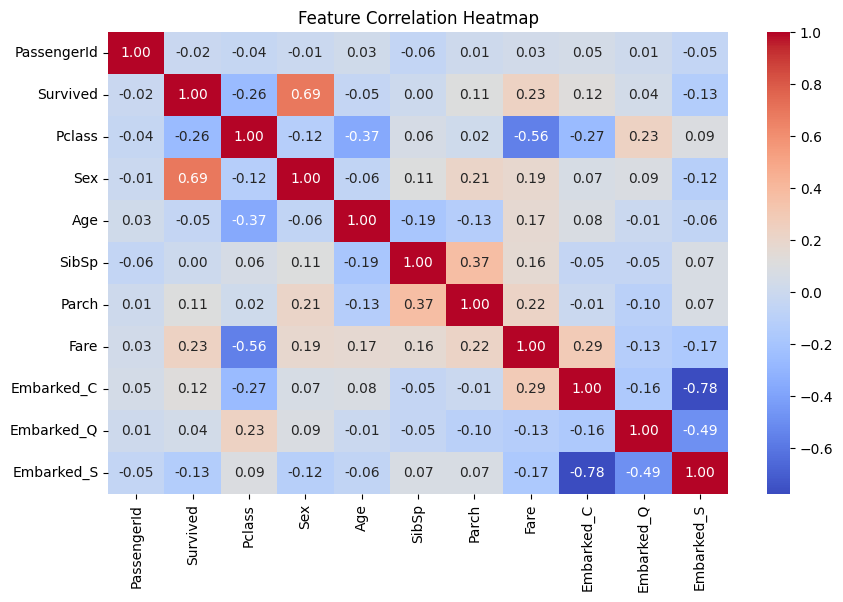

In [44]:
# ============================================================
# CORRELATION MATRIX (ALL NUMERIC VARIABLES)
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Keep only numeric columns
numeric_df = combined_df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

print("Correlation Matrix:\n")
print(corr_matrix)

# ============================================================
# VISUAL HEATMAP
# ============================================================

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [45]:
# ============================================================
# CORRELATION + P-VALUE WITH TARGET (Survived)
# ============================================================

from scipy.stats import pearsonr
import pandas as pd

# Keep only numeric columns
numeric_df = combined_df.select_dtypes(include=['int64', 'float64'])

target = 'Survived'

results = []

for col in numeric_df.columns:
    if col != target:

        # drop NA just in case
        temp_df = numeric_df[[col, target]].dropna()

        corr, p_value = pearsonr(temp_df[col], temp_df[target])

        results.append([col, corr, p_value])

# Create results dataframe
corr_pvalues_df = pd.DataFrame(results, columns=[
    'Feature',
    'Correlation_with_Survived',
    'P_value'
])

# Sort by absolute correlation
corr_pvalues_df['Abs_Corr'] = corr_pvalues_df['Correlation_with_Survived'].abs()
corr_pvalues_df = corr_pvalues_df.sort_values(by='Abs_Corr', ascending=False)

print(corr_pvalues_df)

       Feature  Correlation_with_Survived        P_value  Abs_Corr
2          Sex                   0.688371  1.770723e-184  0.688371
1       Pclass                  -0.264710   1.988065e-22  0.264710
6         Fare                   0.233568   1.117616e-17  0.233568
9   Embarked_S                  -0.133020   1.368450e-06  0.133020
7   Embarked_C                   0.121156   1.105493e-05  0.121156
5        Parch                   0.108919   7.857864e-05  0.108919
3          Age                  -0.048483   7.952245e-02  0.048483
8   Embarked_Q                   0.040950   1.386689e-01  0.040950
0  PassengerId                  -0.020370   4.615178e-01  0.020370
4        SibSp                   0.002370   9.317226e-01  0.002370


In [46]:
# ============================================================
# P-VALUES ONLY (WITH SURVIVED)
# ============================================================

from scipy.stats import pearsonr

numeric_df = combined_df.select_dtypes(include=['int64', 'float64'])
target = 'Survived'

for col in numeric_df.columns:
    if col != target:

        temp_df = numeric_df[[col, target]].dropna()
        _, p_value = pearsonr(temp_df[col], temp_df[target])

        print(f"{col} : p-value = {p_value:.6f}")

PassengerId : p-value = 0.461518
Pclass : p-value = 0.000000
Sex : p-value = 0.000000
Age : p-value = 0.079522
SibSp : p-value = 0.931723
Parch : p-value = 0.000079
Fare : p-value = 0.000000
Embarked_C : p-value = 0.000011
Embarked_Q : p-value = 0.138669
Embarked_S : p-value = 0.000001


In [47]:
# ============================================================
# SURVIVAL RATE: WITH vs WITHOUT SIBLINGS/SPOUSE
# ============================================================

combined_df['Has_SibSp'] = combined_df['SibSp'].apply(lambda x: 1 if x > 0 else 0)

sibsp_survival = combined_df.groupby('Has_SibSp')['Survived'].mean()

print("Survival Rate (SibSp):")
print(sibsp_survival)

Survival Rate (SibSp):
Has_SibSp
0    0.334456
1    0.468900
Name: Survived, dtype: float64


In [48]:
# ============================================================
# SURVIVAL RATE: WITH vs WITHOUT PARENTS/CHILDREN
# ============================================================

combined_df['Has_Parch'] = combined_df['Parch'].apply(lambda x: 1 if x > 0 else 0)

parch_survival = combined_df.groupby('Has_Parch')['Survived'].mean()

print("Survival Rate (Parch):")
print(parch_survival)

Survival Rate (Parch):
Has_Parch
0    0.331337
1    0.527687
Name: Survived, dtype: float64


In [49]:
combined_df['Has_Family'] = combined_df['SibSp'] + combined_df['Parch']
combined_df['Has_Family'] = combined_df['Has_Family'].apply(lambda x: 1 if x > 0 else 0)

print(combined_df.groupby('Has_Family')['Survived'].mean())

Has_Family
0    0.292405
1    0.506744
Name: Survived, dtype: float64


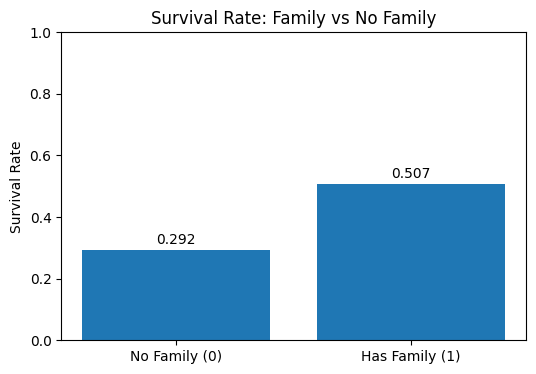

In [50]:
import matplotlib.pyplot as plt

# Data
family_survival = combined_df.groupby('Has_Family')['Survived'].mean()

# Plot
plt.figure(figsize=(6,4))
plt.bar(['No Family (0)', 'Has Family (1)'], family_survival)

plt.title("Survival Rate: Family vs No Family")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

# values on bars
for i, v in enumerate(family_survival):
    plt.text(i, v + 0.02, str(round(v, 3)), ha='center')

plt.show()

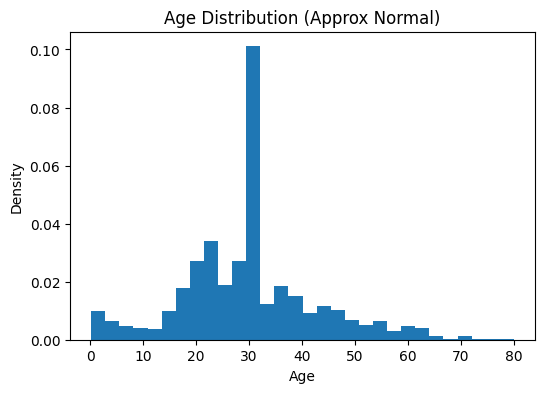

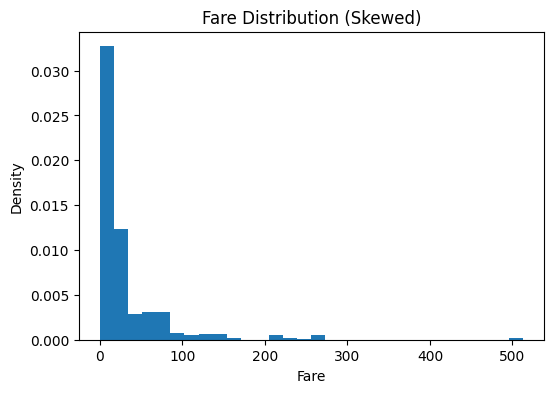

In [51]:
import matplotlib.pyplot as plt

# ============================================================
# AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,4))
plt.hist(combined_df['Age'], bins=30, density=True)
plt.title("Age Distribution (Approx Normal)")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

# ============================================================
# FARE DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,4))
plt.hist(combined_df['Fare'], bins=30, density=True)
plt.title("Fare Distribution (Skewed)")
plt.xlabel("Fare")
plt.ylabel("Density")
plt.show()

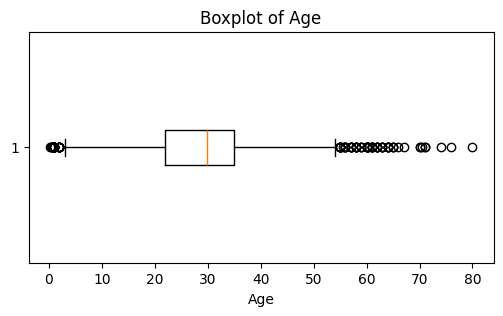

In [54]:
import matplotlib.pyplot as plt

#Boxplot: Age
plt.figure(figsize=(6,3))
plt.boxplot(combined_df['Age'], vert=False)
plt.title("Boxplot of Age")
plt.xlabel("Age")
plt.show()



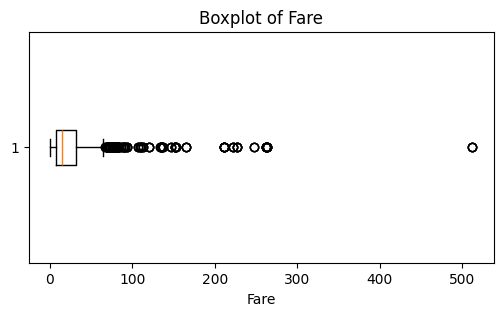

In [55]:
#Boxplot: Fare

plt.figure(figsize=(6,3))
plt.boxplot(combined_df['Fare'], vert=False)
plt.title("Boxplot of Fare")
plt.xlabel("Fare")
plt.show()